<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>

In [1]:
# Parameters
sensible_attribute = "age-sex-race"


### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [2]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [3]:
dataset_path = 'COMPAS/compas-preprocessed-binary.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race']
mapping= {
    'age':{
        0: 'age<35',
        1: 'age>35',
    },
    'sex':{
        0: 'fem',
        1: 'mal'
    },
    'race':{
        0: 'African',
        1: 'AsiaWhiHispNatOth'
    }
}
feature_cols= df.columns
target_variable = 'is_violent_recid'
target_variable_labels= ['0','1']
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,1,1,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0,0
2,1,0,1,0,5,0,0,0,0
3,1,0,0,0,3,0,0,0,1
4,1,0,0,0,4,0,1,4,0


In [4]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Choose subgroup

In [5]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['age', 'sex', 'race', 'age-sex-race']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [6]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


age
Precision: 0.7241379310344828, Recall: 0.11666666666666667, Accuracy: 0.939206406989443, F1: 0.20095693779904306
{np.int64(1): array([[948,   1],
       [ 45,   7]]), np.int64(0): array([[1611,    7],
       [ 114,   14]])}
age
Precision: 0.7619047619047619, Recall: 0.08695652173913043, Accuracy: 0.9370451237263464, F1: 0.15609756097560976
{np.int64(1): array([[953,   2],
       [ 43,   3]]), np.int64(0): array([[1606,    3],
       [ 125,   13]])}


sex
Precision: 0.7241379310344828, Recall: 0.11666666666666667, Accuracy: 0.939206406989443, F1: 0.20095693779904306
{np.int64(1): array([[2060,    8],
       [ 136,   17]]), np.int64(0): array([[499,   0],
       [ 23,   4]])}
sex
Precision: 0.7619047619047619, Recall: 0.08695652173913043, Accuracy: 0.9370451237263464, F1: 0.15609756097560976
{np.int64(1): array([[2061,    5],
       [ 152,   14]]), np.int64(0): array([[498,   0],
       [ 16,   2]])}


race
Precision: 0.7241379310344828, Recall: 0.11666666666666667, Accuracy: 0.939206406989443, F1: 0.20095693779904306
{np.int64(1): array([[1242,    1],
       [  56,    6]]), np.int64(0): array([[1317,    7],
       [ 103,   15]])}
race
Precision: 0.7619047619047619, Recall: 0.08695652173913043, Accuracy: 0.9370451237263464, F1: 0.15609756097560976
{np.int64(1): array([[1197,    2],
       [  69,    6]]), np.int64(0): array([[1362,    3],
       [  99,   10]])}


age-sex-race
Precision: 0.782608695652174, Recall: 0.1, Accuracy: 0.939206406989443, F1: 0.17733990147783252
{'111': array([[459,   0],
       [ 16,   0]]), '011': array([[503,   1],
       [ 32,   3]]), '010': array([[798,   3],
       [ 66,   7]]), '101': array([[127,   0],
       [  2,   3]]), '001': array([[153,   0],
       [  6,   0]]), '110': array([[303,   1],
       [ 25,   4]]), '100': array([[59,  0],
       [ 2,  0]]), '000': array([[160,   0],
       [ 13,   1]])}
age-sex-race
Precision: 0.6875, Recall: 0.059782608695652176, Accuracy: 0.9352256186317321, F1: 0.11


{'111': array([[413,   1],
       [ 22,   0]]), '011': array([[512,   1],
       [ 43,   4]]), '010': array([[772,   2],
       [ 74,   5]]), '101': array([[125,   0],
       [  4,   0]]), '001': array([[147,   0],
       [  2,   0]]), '110': array([[364,   1],
       [ 16,   2]]), '100': array([[51,  0],
       [ 2,  0]]), '000': array([[175,   0],
       [ 10,   0]])}


# Plot Confusion Matrix

In [7]:
def plot_confusion_matrix(cm_data, forwhat=''):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

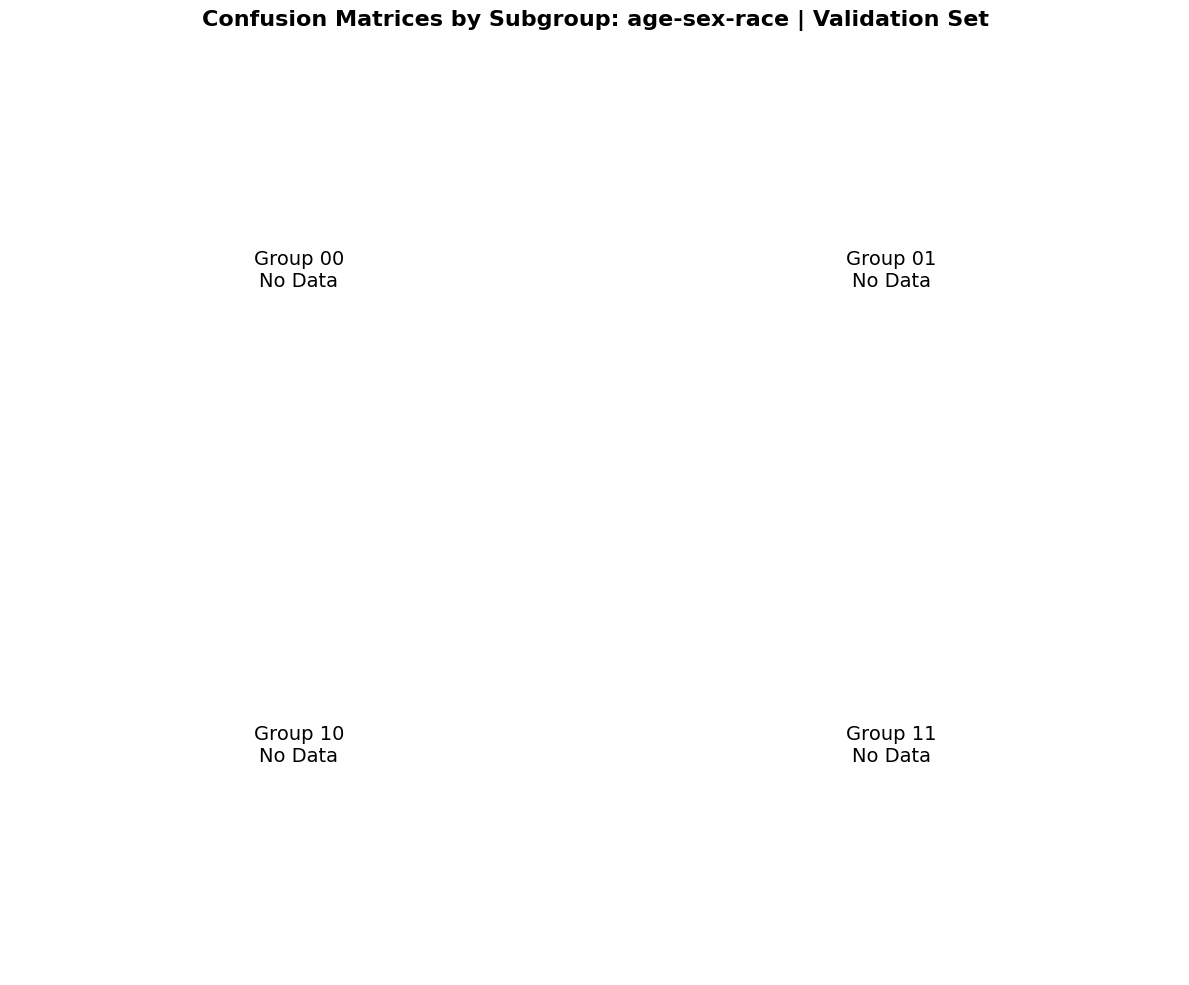

In [8]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set')

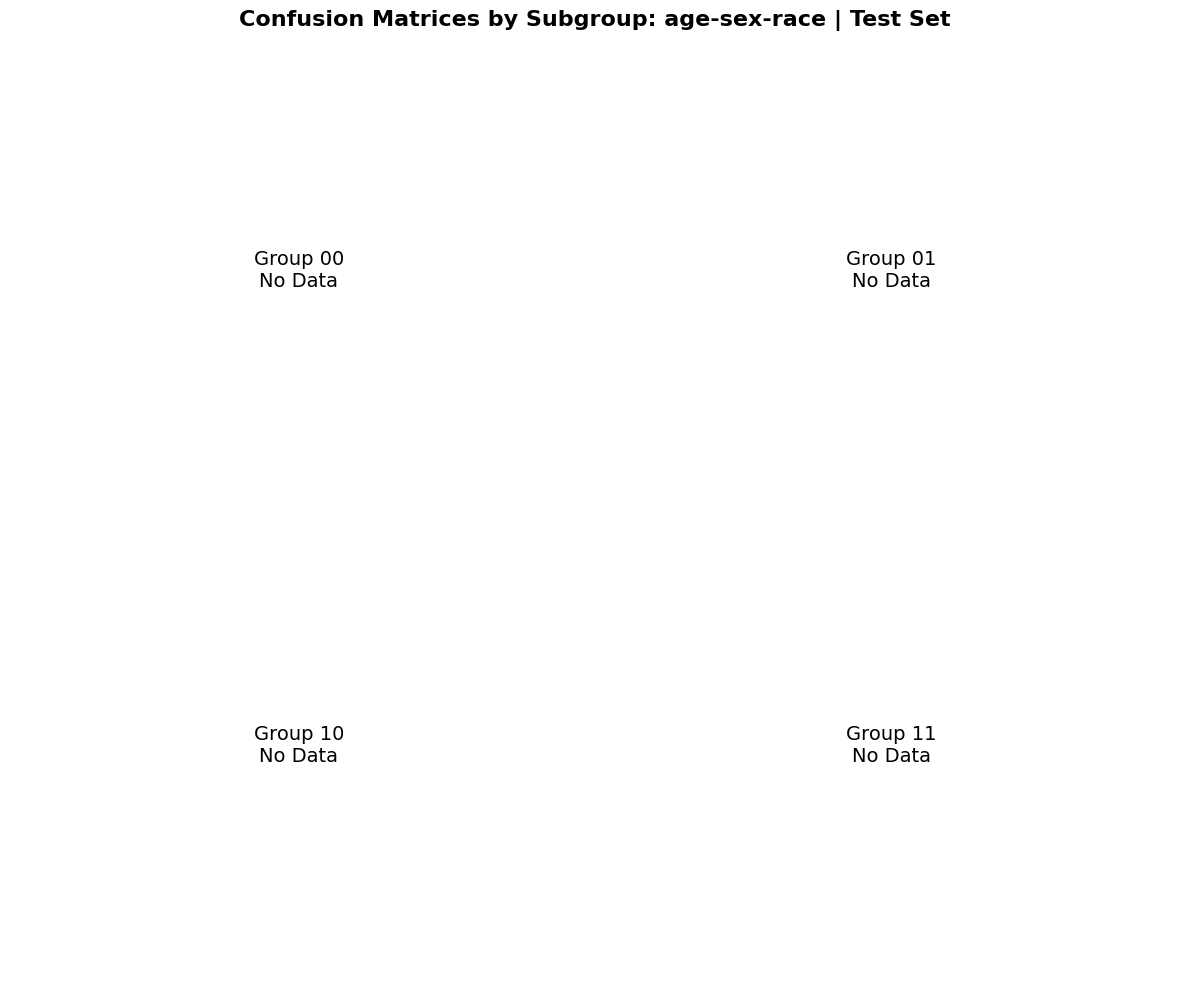

In [9]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set')

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [10]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

KeyError: 'age-sex'

# Weights Functions

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [ ]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [ ]:
def compute_weights_notsized(lambda_=5.0, m='FPN'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [ ]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [ ]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [ ]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [ ]:
weights_sized = compute_weights_sized(10.0)

---

In [ ]:
def compute_fixed_weights(lambda_=5.0, m='FPN', fixed_weights=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }

    weights_notsized = fixed_weights # in the form of a dictionary {'00': weight1, '01': weight2, ...}

    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized

# Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [ ]:
def compute_penalties_after_reweighting(weights, fairness_metric):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)
    
    # Compute fairness metrics for ALL attributes (individual + combined)
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}
    
    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

### Example

In [ ]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

---

# Penalty After Reweighting Plots

### Utils

In [ ]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

## Penalty before and after reweighting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

In [ ]:
# lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

# for l in lambdas:
#     penalties_ontest_after_reweighting = {}

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
#     for metric in fair_metrics:
#         # print("FAIRNESS METRIC:", metric)
#         weights_notsized = compute_weights_notsized(l, metric)
#         penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
#         # print("\n")

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
#     plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
#                                             sensible_attribute, mapping)

In [ ]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

In [ ]:
metrics = ['FPN']
penalties_ontest_after_reweighting = {}
for metric in metrics:
    weights_notsized = compute_weights_notsized(2, metric)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping)

---

# Analysis of subgroup distribution

1. **How many samples per subgroup?**
2. **How many positive (y=1) vs negative (y=0) per subgroup?**
3. **Is each subgroup balanced enough?**

### Utils

In [ ]:
# Step 1: Analyze Subgroup Distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the full dataset
df_analysis = pd.read_csv(dataset_path)

# Create combined attribute column
individual_attrs = sensible_attribute.split('-')
df_analysis[sensible_attribute] = df_analysis[individual_attrs[0]].astype(str) + df_analysis[individual_attrs[1]].astype(str)

print("="*100)
print("SUBGROUP DISTRIBUTION ANALYSIS")
print("="*100)
print(f"\nDataset: {dataset_path}")
print(f"Total samples: {len(df_analysis)}")
print(f"Sensitive attribute: {sensible_attribute}")
print(f"Target variable: {target_variable}")

# Get all subgroups
subgroups = sorted(df_analysis[sensible_attribute].unique())

# Create summary table
print("\n" + "-"*100)
print(f"{'Subgroup':<12} | {'Decoded':<25} | {'Total':>8} | {'Pos (y=1)':>10} | {'Neg (y=0)':>10} | {'Pos Rate':>10} | {'Balanced?':>10}")
print("-"*100)

distribution_data = []

for group in subgroups:
    # Decode the group
    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
    
    # Get counts
    group_data = df_analysis[df_analysis[sensible_attribute] == group]
    total = len(group_data)
    positive = (group_data[target_variable] == 1).sum()
    negative = (group_data[target_variable] == 0).sum()
    pos_rate = positive / total if total > 0 else 0
    
    # Determine if balanced (within 40-60% range for positive rate)
    balanced = "Yes" if 0.3 <= pos_rate <= 0.7 else "No"
    
    # Check if we can extract 10+10 anchor samples
    can_anchor_10 = "✓" if positive >= 10 and negative >= 10 else "✗"
    
    distribution_data.append({
        'group': group,
        'decoded': decoded,
        'total': total,
        'positive': positive,
        'negative': negative,
        'pos_rate': pos_rate,
        'balanced': balanced,
        'can_anchor_10': can_anchor_10
    })
    
    print(f"{group:<12} | {decoded:<25} | {total:>8} | {positive:>10} | {negative:>10} | {pos_rate:>9.1%} | {balanced:>10}")

print("-"*100)

# Summary statistics
print("\n" + "="*100)
print("FEASIBILITY CHECK: Can we extract anchor samples?")
print("="*100)

for n_anchor in [5, 10, 15, 20]:
    print(f"\n{n_anchor} positive + {n_anchor} negative per subgroup:")
    for d in distribution_data:
        can = "✓" if d['positive'] >= n_anchor and d['negative'] >= n_anchor else "✗"
        shortage_pos = max(0, n_anchor - d['positive'])
        shortage_neg = max(0, n_anchor - d['negative'])
        status = "OK" if can == "✓" else f"Need +{shortage_pos} pos, +{shortage_neg} neg"
        print(f"  {d['group']} ({d['decoded']:18s}): {can} {status}")

In [ ]:
# Detailed view: Distribution within each split (train/val/test)
from sklearn.model_selection import train_test_split

print("="*100)
print("DISTRIBUTION ACROSS TRAIN/VAL/TEST SPLITS (Current Random Split)")
print("="*100)

# Use current split
Y = df_analysis[target_variable]
X = df_analysis.drop(target_variable, axis=1)

# Recreate the splits
X_train_temp, X_temp, y_train_temp, y_temp = train_test_split(X, Y, test_size=0.3, random_state=1)
X_val_temp, X_test_temp, y_val_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

splits = {
    'Train (70%)': (X_train_temp, y_train_temp),
    'Val (15%)': (X_val_temp, y_val_temp),
    'Test (15%)': (X_test_temp, y_test_temp)
}

# Analyze each split
for split_name, (X_split, y_split) in splits.items():
    print(f"\n{split_name}:")
    print("-"*90)
    print(f"  {'Subgroup':<12} | {'Decoded':<20} | {'Total':>8} | {'Pos':>8} | {'Neg':>8} | {'Pos Rate':>10}")
    print("  " + "-"*80)
    
    # Get sensitive attribute for this split
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    
    for group in subgroups:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        mask = sens_split == group
        total = mask.sum()
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        pos_rate = positive / total if total > 0 else 0
        
        print(f"  {group:<12} | {decoded:<20} | {total:>8} | {positive:>8} | {negative:>8} | {pos_rate:>9.1%}")

print("\n" + "="*100)
print("KEY OBSERVATION: Check if any subgroup has 0 positives or 0 negatives in any split!")
print("="*100)

In [ ]:
# Visualization: Subgroup Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total samples per subgroup
ax1 = axes[0]
groups = [d['group'] for d in distribution_data]
totals = [d['total'] for d in distribution_data]
decoded_labels = [d['decoded'] for d in distribution_data]

bars = ax1.bar(groups, totals, color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subgroup')
ax1.set_xticks(range(len(groups)))
ax1.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)

# Add value labels on bars
for bar, total in zip(bars, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{total:,}', ha='center', va='bottom', fontsize=10)

# Plot 2: Positive vs Negative per subgroup (stacked)
ax2 = axes[1]
positives = [d['positive'] for d in distribution_data]
negatives = [d['negative'] for d in distribution_data]

x = np.arange(len(groups))
width = 0.6

bars_neg = ax2.bar(x, negatives, width, label='Negative (y=0)', color='#3498db')
bars_pos = ax2.bar(x, positives, width, bottom=negatives, label='Positive (y=1)', color='#e74c3c')

ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Number of Samples')
ax2.set_title('Positive vs Negative Labels per Subgroup')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax2.legend()

# Plot 3: Positive rate per subgroup
ax3 = axes[2]
pos_rates = [d['pos_rate'] * 100 for d in distribution_data]

bars = ax3.bar(groups, pos_rates, color=['#2ecc71' if 30 <= r <= 70 else '#e74c3c' for r in pos_rates])
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Balanced (50%)')
ax3.axhline(y=30, color='gray', linestyle=':', linewidth=1)
ax3.axhline(y=70, color='gray', linestyle=':', linewidth=1)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Class Balance per Subgroup')
ax3.set_xticks(range(len(groups)))
ax3.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax3.set_ylim(0, 100)
ax3.legend()

# Add value labels
for bar, rate in zip(bars, pos_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Distribution Analysis: {sensible_attribute}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Visualization: Compare distributions across splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Collect data for all splits
split_data = {}
for split_name, (X_split, y_split) in splits.items():
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    split_data[split_name] = {
        'pos': [],
        'neg': [],
        'pos_rate': []
    }
    for group in subgroups:
        mask = sens_split == group
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        total = positive + negative
        split_data[split_name]['pos'].append(positive)
        split_data[split_name]['neg'].append(negative)
        split_data[split_name]['pos_rate'].append(positive / total * 100 if total > 0 else 0)

# Plot 1: Positive counts across splits
ax1 = axes[0, 0]
x = np.arange(len(subgroups))
width = 0.25
for i, (split_name, data) in enumerate(split_data.items()):
    ax1.bar(x + i*width, data['pos'], width, label=split_name)
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Positive Count (y=1)')
ax1.set_title('Positive Samples per Subgroup Across Splits')
ax1.set_xticks(x + width)
ax1.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Negative counts across splits
ax2 = axes[0, 1]
for i, (split_name, data) in enumerate(split_data.items()):
    ax2.bar(x + i*width, data['neg'], width, label=split_name)
ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Negative Count (y=0)')
ax2.set_title('Negative Samples per Subgroup Across Splits')
ax2.set_xticks(x + width)
ax2.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Positive rate comparison across splits
ax3 = axes[1, 0]
for i, (split_name, data) in enumerate(split_data.items()):
    ax3.bar(x + i*width, data['pos_rate'], width, label=split_name)
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Positive Rate per Subgroup Across Splits')
ax3.set_xticks(x + width)
ax3.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 100)

# Plot 4: Variance in positive rate across splits (indicator of instability)
ax4 = axes[1, 1]
pos_rate_variance = []
for i, group in enumerate(subgroups):
    rates = [split_data[split]['pos_rate'][i] for split in split_data.keys()]
    variance = np.std(rates)
    pos_rate_variance.append(variance)

bars = ax4.bar(subgroups, pos_rate_variance, color=['#e74c3c' if v > 5 else '#2ecc71' for v in pos_rate_variance])
ax4.set_xlabel('Subgroup')
ax4.set_ylabel('Std Dev of Positive Rate (%)')
ax4.set_title('Positive Rate Variability Across Splits\n(Higher = More Unstable)')
ax4.set_xticks(range(len(subgroups)))
ax4.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax4.axhline(y=5, color='gray', linestyle='--', linewidth=1, label='Threshold (5%)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, var in zip(bars, pos_rate_variance):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{var:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution Analysis Across Train/Val/Test Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("INTERPRETATION:")
print("="*100)
print("- High variance in positive rate suggests the split is unstable for that subgroup")
print("- Subgroups with variance > 5% may benefit from fixed anchor samples")
print("- Small subgroups tend to have higher variance due to random sampling effects")

# K-Fold Cross-Validation for Penalty Estimation

**Goal**: Get more stable penalty estimates by averaging across 5 validation folds.

**Process**:
1. Combine Train + Val data (85% of total)
2. Split into 5 folds using StratifiedKFold (preserves class balance)
3. For each fold: train on 4 folds, validate on 1 fold, compute penalties
4. Average penalties across all 5 folds
5. Use averaged penalties to compute final weights
6. Train final model on ALL train+val data with weights → Predict on Test

**Test set (15%) remains completely separate!**

In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold
import xgboost as xgb

def compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold cross-validation for more stable estimates.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*80)
        print(f"K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K={n_folds})")
        print("="*80)
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Initialize storage for penalties per fold
    penalties_per_fold = {m: {g: [] for g in ['00', '01', '10', '11']} for m in fair_metrics}

    # Setup stratified K-fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Val distribution: {val_dist.to_dict()}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes

        # X_fold_train_num = X_fold_train.copy()
        # X_fold_val_num   = X_fold_val.copy()

        # cats = pd.Index(X_fold_train[sensible_attribute].astype(str).unique()).sort_values()
        # cat2code = {c: i for i, c in enumerate(cats)}

        # X_fold_train_num[sensible_attribute] = (
        #     X_fold_train[sensible_attribute].astype(str).map(cat2code).astype(int)
        # )
        # X_fold_val_num[sensible_attribute] = (
        #     X_fold_val[sensible_attribute].astype(str).map(cat2code).fillna(-1).astype(int)
        # )

        
        # Train model on this fold's training data
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in ['00', '01', '10', '11']:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*80)
        print("AVERAGED PENALTIES (across 5 folds)")
        print("="*80)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in ['00', '01', '10', '11']:
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                print(f"  {group}: avg={avg:+.2f}%, std={std:.2f}, folds={[f'{v:.1f}' for v in fold_vals]}")
    
    return penalties_kfold_avg, penalties_per_fold

# Run K-fold penalty computation
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
penalties_kfold_avg, penalties_per_fold = compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5)

## Compute Weights Using K-Fold Averaged Penalties

### Functions

Now we use the more stable K-fold averaged penalties to compute weights, train the final model, and compare with the single-split approach.

### Functions

In [ ]:
def compute_weights_kfold(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

In [ ]:
def compute_penalties_after_reweighting_kfold(weights, X_trainval, y_trainval, fairness_metric='PPE'):
    """
    Train model on FULL train+val data with K-fold weights, evaluate on test set.
    """
    # Convert to numeric for XGBoost
    X_trainval_num = X_trainval.copy()
    X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes
    
    X_test_num = X_test[sensible_attribute].copy()
    X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes
    
    # Train model on full train+val with weights
    model_kfold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_kfold.fit(X_trainval_num, y_trainval, sample_weight=weights)
    
    # Predict on test set
    y_pred_test_kfold = model_kfold.predict(X_test_num)
    
    # Compute fairness metrics
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    df_fresh = pd.read_csv(dataset_path)
    
    fairness_metrics_kfold = {}
    
    for attribute in attributes:
        df_attr = df_fresh.copy()
        
        if '-' in attribute:
            indiv_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs]
            )
        
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_test_kfold, y_test[sensible_attribute], X_test[sensible_attribute],
            target_variable_labels
        )
        
        fairness_metrics_kfold[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_kfold[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    harmonic, _, _ = compute_penalty_2(
        fairness_metrics_kfold, df_fresh,
        individual_attrs[0], individual_attrs[1],
        fairness_metric
    )
    
    return harmonic

# Penalty plots on K-fold

### Weights and penalties computation

In [ ]:
# Compute penalties on test set after K-fold reweighting
penalties_ontest_after_kfold = {}
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, metric)
    penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, metric)

    
print("\nPenalties after K-fold reweighting computed for all metrics.")

In [ ]:
penalties_kfold_avg

In [ ]:
penalties_ontest_after_kfold['FPN']

In [ ]:
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_kfold,
                                        sensible_attribute, mapping)

## Testing on Multiple Lambdas

Note: It might take a while to run, because it needs to compute weights for all fairness metrics, 5 times

In [ ]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
for l in lambdas:
    # Compute penalties on test set after K-fold reweighting
    penalties_ontest_after_kfold = {}
    fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
    for metric in fair_metrics:
        weights_kfold, X_trainval, y_trainval = compute_weights_kfold(l, metric)
        penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, metric)

        
    print("\nPenalties after K-fold reweighting computed for all metrics.")

    fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
    plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_kfold,
                                            sensible_attribute, mapping)

In [ ]:
weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, 'FPN')
penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, 'FPN')
fair_metrics=['FPN']
plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_kfold, sensible_attribute, mapping)

---

# Additional Plots and Info

In [ ]:
# DIAGNOSTIC: Let's investigate the -192 penalty
# Looking at subgroup 00, fold with extreme value

import numpy as np

# Get the FPN penalties for subgroup 00 across all folds
fpn_00_values = penalties_per_fold['FPN']['00']
print("FPN penalties for subgroup '00' across 5 folds:")
print(fpn_00_values)
print(f"\nMean: {np.mean(fpn_00_values):.2f}")
print(f"Median: {np.median(fpn_00_values):.2f}")
print(f"Std Dev: {np.std(fpn_00_values):.2f}")

# Find the fold with the extreme value
extreme_idx = np.argmin(fpn_00_values)  # Index of most negative value
print(f"\nMost extreme value: {fpn_00_values[extreme_idx]:.2f} at fold {extreme_idx}")

# Let's manually recompute that fold to see the actual fairness metric values
print("\n" + "="*80)
print(f"DIAGNOSING FOLD {extreme_idx} - WHY IS PENALTY = {fpn_00_values[extreme_idx]:.2f}?")
print("="*80)

# Re-run that specific fold to get the raw data
attributes = sensible_attribute.split('-') + [sensible_attribute]
individual_attrs = sensible_attribute.split('-')

X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df_original = pd.read_csv(dataset_path)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    if fold_idx != extreme_idx:
        continue
    
    X_fold_val = X_trainval.iloc[val_idx]
    y_fold_val = y_trainval.iloc[val_idx]
    
    # Show distribution
    print(f"\nValidation set distribution in fold {fold_idx}:")
    val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
    for group, count in val_dist.items():
        print(f"  Subgroup {group}: {count} samples")
    
    # Get predictions (train model quickly)
    X_fold_train = X_trainval.iloc[train_idx]
    y_fold_train = y_trainval.iloc[train_idx]
    
    X_fold_train_num = X_fold_train.copy()
    X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
    X_fold_val_num = X_fold_val.copy()
    X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes
    
    model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_fold.fit(X_fold_train_num, y_fold_train)
    y_pred_fold_val = model_fold.predict(X_fold_val_num)
    
    # Compute fairness metrics
    fairness_metrics_fold = {}
    
    for attribute in attributes:
        df_attr = df_original.copy()
        
        if '-' in attribute:
            indiv_attrs_local = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs_local]
            )
        
        sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
        
        cm_dict_fold = compute_cm_group(
            df_attr, attribute, sensible_indexes_fold,
            y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
        )
        
        fairness_metrics_fold[attribute] = {}
        fairness_metrics_fold[attribute]['FPN'], _ = compute_fairness_metrics_and_counts(
            cm_dict_fold, 'FPN', attribute, mapping, dataset_path
        )
    
    # Now show the raw values that went into penalty calculation
    print(f"\nFairness metric values (FPN):")
    attr1 = individual_attrs[0]  # e.g., 'sex'
    attr2 = individual_attrs[1]  # e.g., 'race'
    
    print(f"  Individual attribute '{attr1}': {fairness_metrics_fold[attr1]['FPN']}")
    print(f"  Individual attribute '{attr2}': {fairness_metrics_fold[attr2]['FPN']}")
    print(f"  Combined '{sensible_attribute}': {fairness_metrics_fold[sensible_attribute]['FPN']}")
    
    # Manually compute penalty for subgroup 00
    if 0 in fairness_metrics_fold[attr1]['FPN'] and 0 in fairness_metrics_fold[attr2]['FPN']:
        a = fairness_metrics_fold[attr1]['FPN'][0]
        b = fairness_metrics_fold[attr2]['FPN'][0]
        
        if '00' in fairness_metrics_fold[sensible_attribute]['FPN']:
            c_actual = fairness_metrics_fold[sensible_attribute]['FPN']['00']
        else:
            c_actual = 0
        
        # Harmonic mean
        predicted = (2 * a * b) / (a + b) if (a + b) > 0 else 0
        penalty = ((predicted - c_actual) * 100) / predicted if predicted != 0 else 0
        
        print(f"\nPenalty calculation for subgroup '00':")
        print(f"  a (FPN for {attr1}=0): {a:.6f}")
        print(f"  b (FPN for {attr2}=0): {b:.6f}")
        print(f"  predicted (harmonic mean): {predicted:.6f}")
        print(f"  actual (FPN for {sensible_attribute}='00'): {c_actual:.6f}")
        print(f"  penalty = ((predicted - actual) * 100) / predicted")
        print(f"  penalty = (({predicted:.6f} - {c_actual:.6f}) * 100) / {predicted:.6f}")
        print(f"  penalty = {penalty:.2f}%")
        
        # Show the confusion matrix for subgroup 00
        if '00' in cm_dict_fold:
            cm = cm_dict_fold['00']
            print(f"\nConfusion matrix for subgroup '00' in this fold:")
            print(f"  Raw CM shape: {cm.shape}")
            print(f"  Raw CM:\n{cm}")
            if cm.shape == (2, 2):
                TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
                print(f"  TN={TN}, FP={FP}, FN={FN}, TP={TP}")
                print(f"  Total predictions: {TN + FP + FN + TP}")
                if (FP + FN) > 0:
                    fpn_calc = FP / (FP + FN)
                    print(f"  FPN = FP/(FP+FN) = {FP}/({FP}+{FN}) = {fpn_calc:.6f}")
            else:
                print(f"  Only one class present in this subgroup")
        
    break

In [ ]:
# Visualization: Single-Split vs K-Fold Reweighting Effects
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')

for idx, m in enumerate(fair_metrics[:6]):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    width = 0.25
    
    before_vals = [penalties_ontest[m].get(g, 0) for g in groups]
    after_single = [penalties_ontest_after_reweighting[m].get(g, 0) for g in groups]
    after_kfold = [penalties_ontest_after_kfold[m].get(g, 0) for g in groups]
    
    bars1 = ax.bar(x - width, before_vals, width, label='Before Reweighting', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x, after_single, width, label='After (Single-Split)', color='coral', alpha=0.8)
    bars3 = ax.bar(x + width, after_kfold, width, label='After (K-Fold)', color='green', alpha=0.8)
    
    # Decode group labels
    labels = [f"{g}\n({'-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))])})" 
              for g in groups]
    
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparison: Before vs Single-Split vs K-Fold Reweighting (Test Set Penalties)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: Average Absolute Penalty Change by Approach")
print("="*80)

for m in fair_metrics[:6]:
    before_vals = np.array([abs(penalties_ontest[m].get(g, 0)) for g in groups])
    after_single = np.array([abs(penalties_ontest_after_reweighting[m].get(g, 0)) for g in groups])
    after_kfold = np.array([abs(penalties_ontest_after_kfold[m].get(g, 0)) for g in groups])
    
    print(f"{m}: Before = {before_vals.mean():.2f} | Single-Split = {after_single.mean():.2f} | K-Fold = {after_kfold.mean():.2f}")

In [ ]:
# Compare: Single-split penalties vs K-fold averaged penalties
print("="*100)
print("COMPARISON: Single-Split vs K-Fold Averaged Penalties")
print("="*100)

individual_attrs = sensible_attribute.split('-')

for m in fair_metrics[:5]:  # Show first 5 metrics
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Single-Split':>12} | {'K-Fold Avg':>12} | {'K-Fold Std':>12} | {'Difference':>12}")
    print("  " + "-"*85)
    
    for group in ['00', '01', '10', '11']:
        # Decode group name
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        single_val = penalties_onval[m].get(group, 0)
        kfold_avg = penalties_kfold_avg[m][group]
        kfold_std = np.std(penalties_per_fold[m][group])
        diff = kfold_avg - single_val
        
        print(f"  {group} ({decoded:18s}) | {single_val:+12.2f} | {kfold_avg:+12.2f} | {kfold_std:12.2f} | {diff:+12.2f}")

print("\n" + "="*100)
print("NOTE: Lower std = more stable penalty estimate")
print("      Large difference = single-split was noisy")
print("="*100)

In [ ]:
# Visualize penalty stability: K-fold variance by subgroup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')
metrics_to_plot = ['FPN', 'PPE', 'FPR', 'FPA', 'FNP']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    
    # Get data for this metric
    single_vals = [penalties_onval[metric].get(g, 0) for g in groups]
    kfold_avgs = [penalties_kfold_avg[metric][g] for g in groups]
    kfold_stds = [np.std(penalties_per_fold[metric][g]) for g in groups]
    
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, single_vals, width, label='Single-Split', alpha=0.8, color='#e74c3c')
    bars2 = ax.bar(x + width/2, kfold_avgs, width, yerr=kfold_stds, capsize=5, 
                   label='K-Fold (±std)', alpha=0.8, color='#3498db')
    
    # Decode labels
    decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) 
                      for g in groups]
    
    ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
    ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}: Single-Split vs K-Fold', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n{l}" for g, l in zip(groups, decoded_labels)], fontsize=8)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('Penalty Stability: Single-Split vs 5-Fold Cross-Validation\n(Error bars show standard deviation across folds)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.show()